In [2]:
import pandas as pd

churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

# Удалить столбец: 'RowNumber'
churn_data = churn_data.drop(columns=['RowNumber'])

In [3]:
display(churn_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


None

In [4]:
# %pip install plotly
# pip install scipy
import plotly
import plotly.express as px
plotly.__version__


'6.0.1'

Задание №1.

In [5]:
# Подсчет количества ушедших и лояльных клиентов
status_counts = churn_data["Exited"].value_counts()
status_labels = ["Лояльные клиенты", "Ушедшие клиенты"]

# Построение круговой диаграммы с универсальными цветами
fig = px.pie(
    values=status_counts,
    names=status_labels,
    title="Соотношение ушедших и лояльных клиентов",
    color_discrete_sequence=px.colors.qualitative.Set2  # Универсальная цветовая палитра
)
# Применение смещения к меньшей части (показываем акцент)
fig.update_traces(pull=[0, 0.2])

Согласно графику:

Большая часть клиентов (почти 80%) остаётся лояльной, что говорит об успешности стратегии удержания клиентов.

Однако 20,4% ушедших — это значительная доля, на которую стоит обратить внимание. Возможно, потребуется изучить факторы, которые влияют на отток (например, анализ возрастной группы, уровня доходов или географии), чтобы минимизировать потери клиентов.

Задание №2.

In [6]:
import pandas as pd
import plotly.express as px
import numpy as np
from scipy.stats import gaussian_kde

# Фильтрация данных: пользователи с балансом более 2 500 долларов
filtered_data = churn_data[churn_data["Balance"] > 2500]["Balance"]

# Расчёт данных для сглаживающей кривой плотности (KDE)
density = gaussian_kde(filtered_data)
x_vals = np.linspace(filtered_data.min(), filtered_data.max(), 1000)
density_vals = density(x_vals)

# Расчёт медианы
median_balance = filtered_data.median()

# Построение гистограммы
fig = px.histogram(
    data_frame=filtered_data,
    x=filtered_data,
    nbins=50,
    title="Распределение баланса пользователей с более чем 2,5k$",
    color_discrete_sequence=["#636EFA"]
)

# Добавление названий осей
fig.update_layout(
    xaxis_title="Баланс пользователей",
    yaxis_title="Частота (кол-во клиентов)",
    xaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=20000  # Уменьшение шага между метками на оси X
    ),
    template="plotly_white"
)

# Включение сетки
fig.update_layout(
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

# Добавление линии медианы
fig.add_vline(
    x=median_balance,
    line_dash="dot",
    line_color="orange",
    annotation_text="Медиана",
    annotation_position="top right"
)

# Добавление сглаживающей кривой
fig.add_scatter(
    x=x_vals,
    y=density_vals * len(filtered_data) * 20 * (x_vals[1] - x_vals[0]),  # Масштабирование кривой
    mode="lines",
    line=dict(color="red"),
    name="Сглаживающая кривая (KDE)"
)

fig.show()


Вывод: Основная масса клиентов сосредоточена вокруг медианных значений. При этом существует группа клиентов с более низкими или высокими значениями балансов, что создаёт широкий разброс. Данные характеризуются симметричностью и близостью к нормальному распределению

Задание №3.

In [29]:
import plotly.express as px

# Фильтрация данных: ушедшие и лояльные клиенты
loyal_clients = churn_data[churn_data["Exited"] == 0]["Balance"]
churned_clients = churn_data[churn_data["Exited"] == 1]["Balance"]

# Создание гистограммы
hist_fig = px.histogram(
    data_frame=churn_data,
    x="Balance",
    color="Exited",  # Цветовое кодирование по признаку оттока
    nbins=50,
    title="Распределение баланса клиентов",
    labels={"Exited": "Статус клиента", "Balance": "Баланс клиентов"},  # Уточнённые подписи
    color_discrete_map={0: "blue", 1: "red"}  # Лояльные - синий, ушедшие - красный
)

hist_fig.update_layout(
    xaxis_title="Баланс клиентов",
    yaxis_title="Частота",
    template="plotly_white",
    legend_title="Статус клиента"
)

hist_fig.for_each_trace(lambda trace: trace.update(name="Лояльные клиенты" if trace.name == "0" else "Ушедшие клиенты"))

# Создание Boxplot для ушедших и лояльных клиентов с обновлением оси X
box_fig = px.box(
    data_frame=churn_data,
    x="Exited",
    y="Balance",
    color="Exited",  # Цветовое кодирование по признаку оттока
    title="Распределение баланса по статусу клиентов (Boxplot)",
    labels={"Exited": "Статус клиента", "Balance": "Баланс клиентов"},
    category_orders={"Exited": [0, 1]},  # Упорядочивание статусов
    color_discrete_map={0: "blue", 1: "red"}  # Лояльные - синий, ушедшие - красный
)

box_fig.update_layout(
    xaxis_title="Статус клиента",
    xaxis=dict(
        tickmode="array",
        tickvals=[0, 1],  # Значения по оси X
        ticktext=["Лояльные", "Ушедшие"]  # Подписи для значений
    ),
    yaxis_title="Баланс клиентов",
    template="plotly_white",
    legend_title="Статус клиента"
)

box_fig.for_each_trace(lambda trace: trace.update(name="Лояльные клиенты" if trace.name == "0" else "Ушедшие клиенты"))

# Отображение графиков
hist_fig.show()  # Гистограмма
box_fig.show()  # Boxplot


Ушедшие клиенты в среднем обладают более высокими суммами на накопительных счетах, что может быть связано с неудовлетворённостью уровнем обслуживания, недостатком премиальных программ или привлекательных условий для данной категории. Для удержания таких клиентов банку стоит сосредоточиться на улучшении качества обслуживания, разработке специальных предложений и конкурентных продуктов. Это поможет повысить лояльность и предотвратить отток наиболее ценных пользователей

    Большая часть лояльных клиентов с нулевым балансом (3,117) остаётся в банке благодаря минимальной активности или отсутствию стимулов для ухода. Среди ушедших клиентов 500 с нулевым балансом, вероятно, перестали пользоваться услугами из-за отсутствия ценности. Это указывает на необходимость вовлечения неактивных пользователей и создания предложений, которые мотивируют их к использованию продуктов банка.



Задание №4.

In [8]:
import plotly.express as px

# Создание boxplot для распределения возраста по признаку оттока
fig = px.box(
    data_frame=churn_data,
    x="Exited",
    y="Age",
    color="Exited",
    title="Распределение возраста клиентов по признаку оттока",
    labels={"Exited": "Статус клиента", "Age": "Возраст клиентов"},
    color_discrete_map={0: "blue", 1: "red"}  # Лояльные - синий, ушедшие - красный
)

# Обновление оси X для добавления текстовых подписей
fig.update_layout(
    xaxis=dict(
        tickmode="array",
        tickvals=[0, 1],
        ticktext=["Лояльные", "Ушедшие"]
    ),
    xaxis_title="Статус клиента",
    yaxis_title="Возраст клиентов",
    template="plotly_white"
)

fig.show()


Среди лояльных клиентов больше потенциальных выбросов, особенно в старшей возрастной группе

Возрастная категория, на которую стоит обратить внимание:
    1 Ушедшие клиенты: Средний возраст составляет 44.8 года, медиана — 45 лет, то есть основной возрастной диапазон сосредоточен от 38 до 51 года (межквартильный размах). Эти возрастные группы имеют больше вероятности для оттока, и банк должен сосредоточиться на удержании этой категории.

    2 Лояльные клиенты: Основная категория — молодые клиенты (18–41 лет), так как медиана (36 лет) и среднее (37.4 года) ниже, чем у ушедших. Однако выбросы наблюдаются среди старшей категории (50+ лет).

Рекомендации для банка:
Для удержания клиентов среднего возраста (38–51):

    1 Разработать специализированные предложения для клиентов старше 40 лет (например, пенсионные накопления, долгосрочные инвестиции).

    2 Усилить качество обслуживания для более опытных клиентов, которые, возможно, имеют более строгие требования.

Для лояльной категории: Поддерживать интерес молодых клиентов (18–41 лет) через инновационные услуги, например, цифровые платформы и мобильные приложения.

Задание №5.

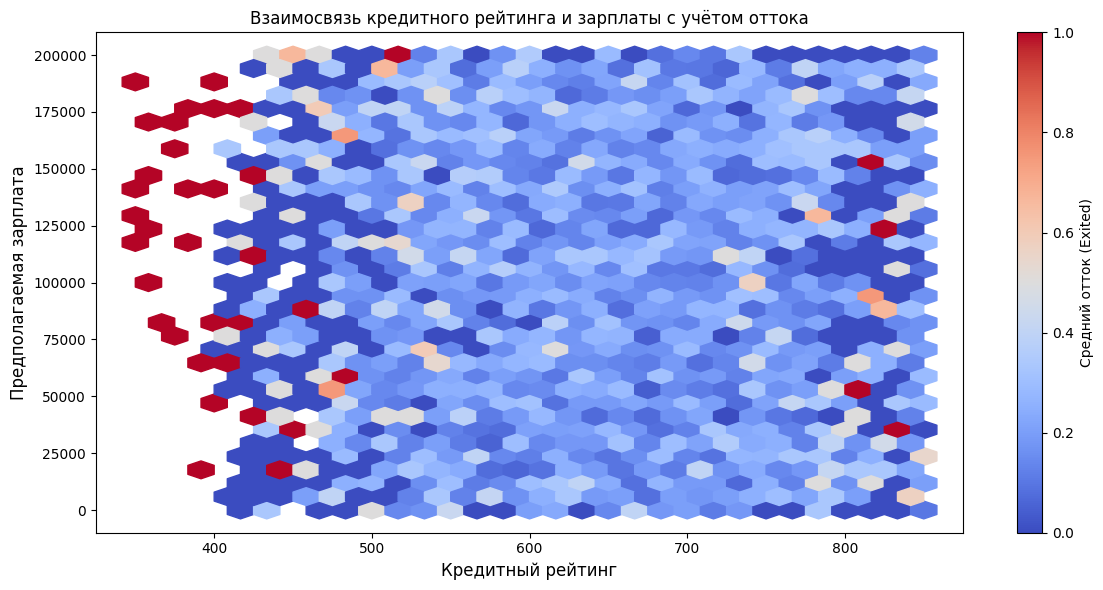

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))  # Увеличиваем размер графика для большего пространства
hb = plt.hexbin(
    churn_data["CreditScore"], 
    churn_data["EstimatedSalary"],
    gridsize=30, 
    cmap="coolwarm", 
    C=churn_data["Exited"], 
    reduce_C_function=np.mean
)
plt.colorbar(hb, label="Средний отток (Exited)")
plt.title("Взаимосвязь кредитного рейтинга и зарплаты с учётом оттока")
plt.xlabel("Кредитный рейтинг", fontsize=12)  # Увеличиваем шрифт подписи оси
plt.ylabel("Предполагаемая зарплата", fontsize=12)
plt.xticks(fontsize=10)  # Увеличиваем шрифт меток на оси X
plt.yticks(fontsize=10)  # Увеличиваем шрифт меток на оси Y
plt.tight_layout()  # Автоматически подгоняем элементы графика
plt.show()


Нет очевидной линейной зависимости между кредитным рейтингом и предполагаемой зарплатой. Однако ушедшие клиенты с более низкими кредитными рейтингами(от 450 и ниже) могут быть менее удовлетворены услугами банка, иеют наибольший риск покинуть банк.
рекомендуется сосредоточиться на улучшении условий для клиентов с низкими кредитными рейтингами, чтобы уменьшить их риски и повысить удовлетворённость

Задание №6.

In [10]:
import pandas as pd
import plotly.express as px

# Группировка данных для расчёта доли ушедших клиентов в каждой группе
gender_churn = churn_data.groupby("Gender")["Exited"].mean().reset_index()

# Переименование колонок для удобства
gender_churn = gender_churn.rename(columns={"Gender": "Пол", "Exited": "Доля ушедших клиентов"})

# Обновление значений в столбце "Пол" на русский
gender_churn["Пол"] = gender_churn["Пол"].replace({"Male": "Мужчины", "Female": "Женщины"})

# Построение столбчатой диаграммы
fig = px.bar(
    gender_churn,
    x="Пол",
    y="Доля ушедших клиентов",
    title="Доля ушедших клиентов по полу",
    text="Доля ушедших клиентов",
    labels={"Пол": "Пол клиентов", "Доля ушедших клиентов": "Средний процент ушедших"},
    color="Пол",
    color_discrete_map={"Мужчины": "blue", "Женщины": "red"}  # Мужчины - синий, Женщины - красный
)

# Настройка отображения
fig.update_traces(texttemplate='%{text:.2%}', textposition="outside")  # Процентный формат
fig.update_layout(
    yaxis=dict(tickformat=".0%", title="Процент ушедших клиентов"),
    template="plotly_white"
)

fig.show()


Женщины покидают банк чаще, чем мужчины. Доля ушедших клиентов среди женщин составляет 25%, тогда как среди мужчин этот показатель равен 16%

Задание №7.

In [11]:
import pandas as pd
import plotly.express as px

# Группировка данных для расчёта доли ушедших клиентов по числу услуг
products_churn = churn_data.groupby("NumOfProducts")["Exited"].mean().reset_index()

# Добавление общего числа клиентов для каждой категории
products_churn["Общее число клиентов"] = churn_data.groupby("NumOfProducts")["Exited"].count().values

# Построение многоуровневой столбчатой диаграммы с интервалом 1
fig = px.bar(
    data_frame=products_churn,
    x="NumOfProducts",
    y="Exited",
    text="Общее число клиентов",
    title="Зависимость оттока клиентов от числа приобретённых услуг",
    labels={
        "NumOfProducts": "Число услуг у клиента",
        "Exited": "Доля ушедших клиентов",
    },
    color="NumOfProducts",  # Цветовое кодирование по числу услуг
    color_continuous_scale="Viridis",
)

# Настройка отображения текста и осей
fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
)
fig.update_layout(
    xaxis=dict(
        title="Число услуг у клиента",
        tickmode="linear",  # Устанавливаем интервал в 1
        dtick=1,
    ),
    yaxis=dict(
        tickformat=".0%",
        title="Доля ушедших клиентов",
    ),
    template="plotly_white",
)

fig.show()


Клиенты с минимальным количеством услуг (1 продукт) и максимальным количеством услуг (4 продукта) имеют высокие показатели оттока. Это указывает на необходимость работы с крайними категориями:

Для клиентов с 1 продуктом: разработка предложений, мотивирующих их расширить сотрудничество.

Для клиентов с 3-4 продуктами: усиление персонализации и устранение факторов, вызывающих неудовлетворённость.

Задание №8.

In [12]:
import pandas as pd
import plotly.express as px

# Группировка данных для расчёта доли ушедших клиентов в каждой группе (активные/неактивные)
active_churn = churn_data.groupby("IsActiveMember")["Exited"].mean().reset_index()

# Замена числовых значений на текстовые (1 -> Активный, 0 -> Неактивный)
active_churn["IsActiveMember"] = active_churn["IsActiveMember"].replace({1: "Активные клиенты", 0: "Неактивные клиенты"})

# Переименование колонок для удобства
active_churn = active_churn.rename(columns={"IsActiveMember": "Статус активности", "Exited": "Доля ушедших клиентов"})

# Построение столбчатой диаграммы
fig = px.bar(
    active_churn,
    x="Статус активности",
    y="Доля ушедших клиентов",
    title="Влияние статуса активности на отток клиентов",
    text="Доля ушедших клиентов",
    labels={"Доля ушедших клиентов": "Средний процент ушедших"},
    color="Статус активности",
    color_discrete_map={"Активные клиенты": "blue", "Неактивные клиенты": "red"}
)

# Настройка отображения
fig.update_traces(texttemplate='%{text:.2%}', textposition="outside")  # Формат текста в процентах
fig.update_layout(
    yaxis=dict(tickformat=".0%", title="Процент ушедших клиентов"),
    template="plotly_white"
)

fig.show()


Неактивные клиенты составляют значительную долю ушедших, и для их удержания важно создать стимулирующие условия, которые мотивируют их активно пользоваться банковскими продуктами. Интеграция персонализированных подходов и общения поможет улучшить лояльность клиентов

Задание №9.

In [13]:
import pandas as pd
import plotly.express as px

# Группировка данных для расчёта доли ушедших клиентов по странам
country_churn = churn_data.groupby("Geography")["Exited"].mean().reset_index()

# Переименование колонок для удобства (используем английские названия)
country_churn = country_churn.rename(columns={"Geography": "Country", "Exited": "Churn Rate"})

# Сортировка для топ-5 стран с наибольшей долей ушедших клиентов
top_5_countries = country_churn.sort_values(by="Churn Rate", ascending=False).head(5)

# Построение тепловой картограммы
fig = px.choropleth(
    country_churn,
    locations="Country",  # Страны на английском
    locationmode="country names",
    color="Churn Rate",
    title="Доля ушедших клиентов по странам",
    color_continuous_scale="Reds",
    labels={"Churn Rate": "Churn Rate"}
)

# Добавление информации о топ-5 странах на график
top_5_text = "<br>".join(
    [f"{row['Country']}: {row['Churn Rate']:.2%}" for _, row in top_5_countries.iterrows()]
)

fig.add_annotation(
    text=f"<b>Топ-3 стран с оттоком:</b><br>{top_5_text}",
    xref="paper", yref="paper",
    x=0.1, y=0.6, showarrow=False,
    align="left", bgcolor="white", bordercolor="black"
)

# Настройка карты
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Процент ушедших", tickformat=".0%")  # Формат процентов
)

fig.show()


Возможные причины высокого оттока в Германии:
Высокие ожидания клиентов: Клиенты в Германии могут быть более требовательны к качеству обслуживания и продуктам, и если банк не отвечает этим ожиданиям, это может приводить к оттоку.

Конкуренция на рынке: Германский финансовый рынок, вероятно, предлагает множество альтернатив с более выгодными условиями, что стимулирует клиентов переходить в другие банки.

Комиссии или условия: Возможно, банк взимает более высокие комиссии или имеет менее привлекательные условия для клиентов в Германии.

Отсутствие локализации: Недостаток персонализированных услуг или предложений, ориентированных на немецкий рынок, мог оказаться значимым фактором.

Задание №10.

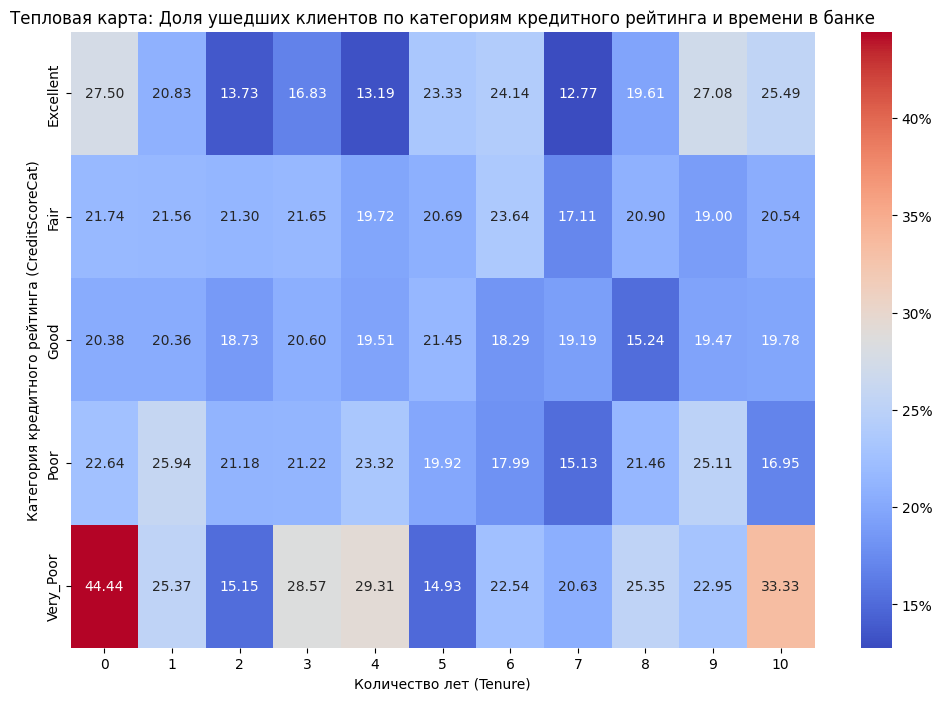

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Функция для преобразования CreditScore в категориальный признак
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

# Создание нового признака CreditScoreCat
churn_data["CreditScoreCat"] = churn_data["CreditScore"].apply(get_credit_score_cat)

# Создание сводной таблицы
pivot_table = churn_data.pivot_table(
    values="Exited", 
    index="CreditScoreCat", 
    columns="Tenure", 
    aggfunc="mean"
)

# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table * 100,  # Умножаем на 100 для перевода в проценты
    annot=True, 
    fmt=".2f",  # Отображение с двумя знаками после запятой
    cmap="coolwarm", 
    cbar_kws={'format': '%.0f%%'}  # Формат процентов для легенды
)

plt.title("Тепловая карта: Доля ушедших клиентов по категориям кредитного рейтинга и времени в банке")
plt.xlabel("Количество лет (Tenure)")
plt.ylabel("Категория кредитного рейтинга (CreditScoreCat)")
plt.show()


Клиенты с низким кредитным рейтингом ("Very_Poor") показывают самый высокий отток, особенно на ранних и поздних этапах обслуживания (до 44.44%). В группе "Poor" отток также выше среднего, особенно при 1 и 9 годах стажа. Клиенты с высоким рейтингом ("Excellent") демонстрируют меньший, но заметный отток на отдельных этапах (27.5% при 0 годах стажа). Банк должен сосредоточиться на удержании клиентов с низким рейтингом, предлагая поддержку, а также на премиальных услугах для категорий с высоким рейтингом. Основные усилия стоит направить на новых клиентов с небольшим стажем, где отток особенно высок

    Общий вывод по анализу данных из базы банка:
    
1. Отток клиентов и основные факторы:

1.1. Основной отток наблюдается среди клиентов с более высокими балансами и доходами, что говорит о необходимости персонализированного подхода и улучшенных условий для премиальных клиентов.

1.2. Женщины, а также клиенты средней возрастной категории (38–51 год) чаще уходят, что требует разработки таргетированных предложений для удержания этих групп.

2. Профиль ушедших клиентов:

2.1. Ушедшие клиенты часто имеют более низкий кредитный рейтинг и, в то же время, более высокий баланс. Это указывает на неудовлетворённость предложениями банка в отношении поддержки клиентов с разными финансовыми статусами.

2.2. Высокая доля ушедших среди неактивных клиентов (26.85%) подчёркивает важность вовлечения и стимулирования пассивных пользователей.

3. Клиенты с 0 балансом:

3.1. Большая часть лояльных клиентов (3,117) имеет нулевой баланс, что говорит о недостаточной вовлечённости. Это ключевая зона для улучшения через образовательные кампании и бонусы.

4. Региональные различия:

4.1. Наибольший отток наблюдается в Германии (32.44%), что требует адаптации услуг и усиления конкурентоспособности в этом регионе.

5 Клиенты с низким и высоким кредитным рейтингом:

5.1. У клиентов с низким рейтингом ("Very_Poor") фиксируется самый высокий отток. Также стоит обратить внимание на премиальных клиентов с отличным рейтингом ("Excellent"), у которых иногда наблюдаются пики оттока из-за несоответствия ожиданий.

    Рекомендации для банка:

1. Ввести премиальные программы и условия для удержания клиентов с высокими доходами и балансами.

2. Разрабатывать персонализированные продукты для женщин и клиентов среднего возраста.

3. Усилить вовлечённость неактивных клиентов через бонусные программы и регулярное взаимодействие.

4. Адаптировать стратегии обслуживания в ключевых регионах с высоким оттоком, таких как Германия.

5. Обратить особое внимание на улучшение условий для клиентов с низким кредитным рейтингом, предоставляя финансовую поддержку и оптимизируя услуги.